# Introduction to Neural Networks

In this activity, you will implement a simple feedforward neural network from scratch using Python. We will use the popular MNIST dataset, which consists of handwritten digits, to train our neural network.

In [5]:
import numpy as np
import gzip
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import seaborn as sns


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


## MNIST dataset

This is a classic dataset in machine learning, consisting of 60,000 training images and 10,000 test images of handwritten digits (0-9). Each image is a 28x28 pixel grayscale image, which can be flattened into a 784-dimensional vector for input into our neural network. The goal is to classify each image into one of the 10 digit classes. The following code will load them into memory.

In [7]:
def load_mnist_dataset(mnist_path):
    x_trainval = get_images(Path(mnist_path)/Path('train-images-idx3-ubyte.gz'))
    y_trainval = get_labels(Path(mnist_path)/Path('train-labels-idx1-ubyte.gz'))

    x_train = x_trainval[:50000]
    y_train = y_trainval[:50000]

    x_val = x_trainval[50000:]
    y_val = y_trainval[50000:]

    x_test = get_images(Path(mnist_path)/Path('t10k-images-idx3-ubyte.gz'))
    y_test = get_labels(Path(mnist_path)/Path('t10k-labels-idx1-ubyte.gz'))

    return x_train, y_train, x_val, y_val, x_test, y_test

def get_labels(path):
    with gzip.open(path, 'rb') as data:
        labels = data.read()[8:]
        return np.frombuffer(labels, dtype=np.uint8)

def get_images(path):
    with gzip.open(path, 'rb') as data:
        _ = int.from_bytes(data.read(4), 'big')
        num_images = int.from_bytes(data.read(4), 'big')
        rows = int.from_bytes(data.read(4), 'big')
        cols = int.from_bytes(data.read(4), 'big')
        images = data.read()
        return np.frombuffer(images, dtype=np.uint8).reshape((num_images, rows, cols))


In [9]:
x_train, y_train, x_val, y_val, x_test, y_test = load_mnist_dataset('/content')

The loaded images are still in 28x28 format, so we will flatten them into 784-dimensional vectors. Normally we would do a random shuffle of the training data before extracting the validation set, but for now we will just take the last 10,000 samples as our validation set.

In [10]:
x_train = x_train.copy().reshape(50000, -1).astype(np.float32)
y_train = y_train.copy().reshape(50000, 1)

x_val = x_val.copy().reshape(10000, -1).astype(np.float32)
y_val = y_val.copy().reshape(10000, 1)

x_test = x_test.copy().reshape(10000, -1).astype(np.float32)
y_test = y_test.copy().reshape(10000, 1)

We can also use matplotlib to visualize the images in the dataset. Each image is a 28x28 pixel grayscale image, which can be displayed using the `imshow` function from matplotlib.

In [11]:
def plot_number(image):
    plt.figure(figsize=(5,5))
    plt.imshow(image.reshape((28,28)), cmap=plt.get_cmap('gray'))
    plt.axis('off')
    plt.show()

Every time you run this cell, a random number from the training set will be displayed. You can run it multiple times to see different images from the dataset.

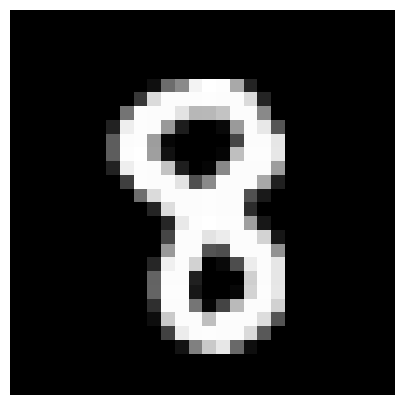

'Label: 8'

In [12]:
random_idx = np.random.randint(0, x_train.shape[0])
plot_number(x_train[random_idx])
display(f"Label: {y_train[random_idx].squeeze()}")

## Defining the Neural Network

In [13]:
class MnistDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).to(device)
        self.y = torch.tensor(y, dtype=torch.long).view(-1).to(device)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [14]:
train_data = MnistDataset(x_train, y_train)
val_data = MnistDataset(x_val, y_val)
test_data = MnistDataset(x_test, y_test)

In [32]:
def train(_model, _train_loader, _val_loader, _criterion, _optimizer, _num_epochs):
    training_losses = []
    validation_losses = []

    patience = 3
    epocas_sin_mejora = 0

    for epoch in range(_num_epochs):
        _model.train()
        running_loss = 0.0
        correct = 0

        for X_batch, y_batch in tqdm(_train_loader, desc=f"Epoch {epoch+1}/{_num_epochs}"):
            _optimizer.zero_grad()
            outputs = _model(X_batch)
            loss = _criterion(outputs, y_batch)
            loss.backward()
            _optimizer.step()

            running_loss += loss.item() * X_batch.size(0)
            correct += (outputs.argmax(1) == y_batch).sum().item()

        epoch_train_loss = running_loss / len(_train_loader.dataset)
        epoch_train_acc  = correct / len(_train_loader.dataset)

        _model.eval()
        val_loss = 0.0
        val_correct = 0

        with torch.no_grad():
            for X_val, y_val in _val_loader:
                val_outputs = _model(X_val)
                val_loss    += _criterion(val_outputs, y_val).item() * X_val.size(0)
                val_correct += (val_outputs.argmax(1) == y_val).sum().item()

        epoch_val_loss = val_loss / len(_val_loader.dataset)
        epoch_val_acc  = val_correct / len(_val_loader.dataset)

        print(f"epoch {epoch+1} loss: {epoch_train_loss:.2f} acc: {epoch_train_acc:.4f} (train) | "
              f"loss: {epoch_val_loss:.2f} acc: {epoch_val_acc:.4f} (val)")

        training_losses.append(epoch_train_loss)
        validation_losses.append(epoch_val_loss)

        if len(validation_losses) > 1 and epoch_val_loss >= validation_losses[-2]:
            epocas_sin_mejora += 1
            if epocas_sin_mejora >= patience:
                print("Stopping training: no improvement for 3 epochs.")
                break
        else:
            epocas_sin_mejora = 0

    return training_losses, validation_losses



In [33]:
train_subset = torch.utils.data.Subset(train_data, indices=range(50000))

model = nn.Sequential(
    nn.Linear(784, 512),
    nn.ReLU(),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
num_epochs = 50
batch_size = 64

train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size)

train_losses, val_losses = train(model, train_loader, val_loader, criterion, optimizer, num_epochs)



Epoch 1/50: 100%|██████████| 782/782 [00:01<00:00, 430.24it/s]


epoch 1 loss: 0.25 acc: 0.9259 (train) | loss: 0.19 acc: 0.9460 (val)


Epoch 2/50: 100%|██████████| 782/782 [00:01<00:00, 417.81it/s]


epoch 2 loss: 0.12 acc: 0.9636 (train) | loss: 0.14 acc: 0.9636 (val)


Epoch 3/50: 100%|██████████| 782/782 [00:01<00:00, 408.76it/s]


...

epoch 10 loss: 0.05 acc: 0.9865 (train) | loss: 0.12 acc: 0.9709 (val)


Epoch 11/50: 100%|██████████| 782/782 [00:01<00:00, 410.83it/s]


epoch 11 loss: 0.05 acc: 0.9874 (train) | loss: 0.14 acc: 0.9742 (val)


Epoch 12/50: 100%|██████████| 782/782 [00:01<00:00, 414.67it/s]


epoch 12 loss: 0.05 acc: 0.9878 (train) | loss: 0.15 acc: 0.9731 (val)
Stopping training: no improvement for 3 epochs.


In [35]:
model2 = nn.Sequential(
    nn.Linear(784, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 10)
).to(device)

criterion2  = nn.CrossEntropyLoss()
optimizer2  = torch.optim.SGD(model2.parameters(), lr=0.01)
num_epochs2 = 50
batch_size2 = 128

train_loader2 = DataLoader(train_data, batch_size=batch_size2, shuffle=True)
val_loader2   = DataLoader(val_data,   batch_size=batch_size2, shuffle=False)

train_losses2, val_losses2 = train(model2, train_loader2, val_loader2, criterion2, optimizer2, num_epochs2)

Epoch 1/50: 100%|██████████| 391/391 [00:00<00:00, 450.94it/s]


epoch 1 loss: 0.37 acc: 0.8896 (train) | loss: 0.18 acc: 0.9479 (val)


Epoch 2/50: 100%|██████████| 391/391 [00:00<00:00, 457.86it/s]


epoch 2 loss: 0.14 acc: 0.9598 (train) | loss: 0.16 acc: 0.9527 (val)


Epoch 3/50: 100%|██████████| 391/391 [00:00<00:00, 459.30it/s]


...

epoch 15 loss: 0.00 acc: 1.0000 (train) | loss: 0.10 acc: 0.9762 (val)


Epoch 16/50: 100%|██████████| 391/391 [00:00<00:00, 458.04it/s]


epoch 16 loss: 0.00 acc: 1.0000 (train) | loss: 0.10 acc: 0.9757 (val)


Epoch 17/50: 100%|██████████| 391/391 [00:00<00:00, 457.08it/s]


epoch 17 loss: 0.00 acc: 1.0000 (train) | loss: 0.10 acc: 0.9763 (val)
Stopping training: no improvement for 3 epochs.


In [36]:
model3 = nn.Sequential(
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 10)
).to(device)

criterion3  = nn.CrossEntropyLoss()
optimizer3  = torch.optim.Adam(model3.parameters(), lr=0.0001)
num_epochs3 = 50
batch_size3 = 32

train_loader3 = DataLoader(train_data, batch_size=batch_size3, shuffle=True)
val_loader3   = DataLoader(val_data,   batch_size=batch_size3, shuffle=False)

train_losses3, val_losses3 = train(model3, train_loader3, val_loader3, criterion3, optimizer3, num_epochs3)


Epoch 1/50: 100%|██████████| 1563/1563 [00:03<00:00, 508.55it/s]


epoch 1 loss: 0.61 acc: 0.8501 (train) | loss: 0.22 acc: 0.9370 (val)


Epoch 2/50: 100%|██████████| 1563/1563 [00:03<00:00, 515.11it/s]


epoch 2 loss: 0.18 acc: 0.9471 (train) | loss: 0.16 acc: 0.9521 (val)


Epoch 3/50: 100%|██████████| 1563/1563 [00:04<00:00, 375.59it/s]


...

epoch 10 loss: 0.02 acc: 0.9934 (train) | loss: 0.12 acc: 0.9716 (val)


Epoch 11/50: 100%|██████████| 1563/1563 [00:03<00:00, 498.30it/s]


epoch 11 loss: 0.02 acc: 0.9940 (train) | loss: 0.13 acc: 0.9705 (val)


Epoch 12/50: 100%|██████████| 1563/1563 [00:03<00:00, 496.75it/s]


epoch 12 loss: 0.01 acc: 0.9958 (train) | loss: 0.15 acc: 0.9696 (val)
Stopping training: no improvement for 3 epochs.


## Testing the model

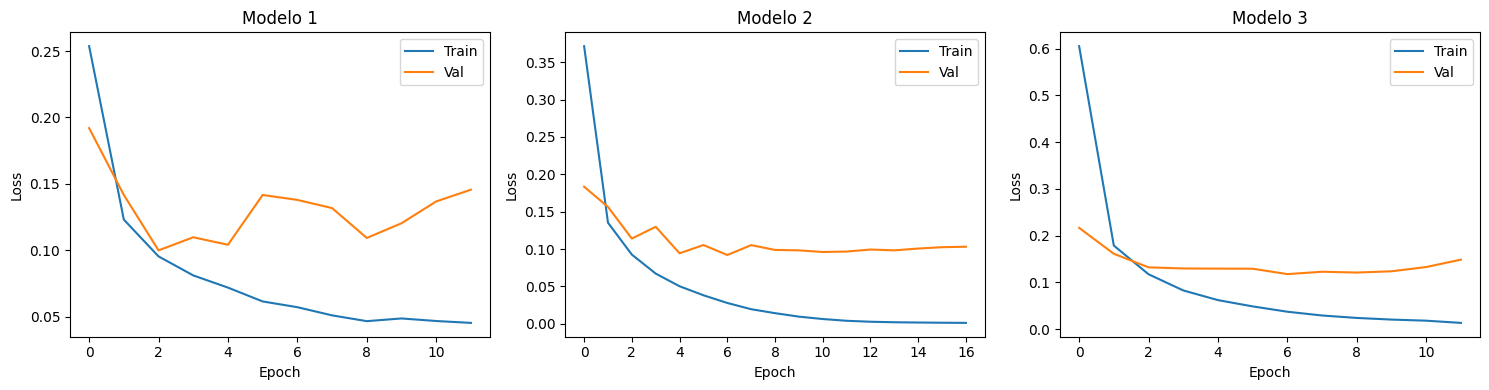

Test Accuracy Modelo 1: 0.9754
Test Accuracy Modelo 2: 0.9756
Test Accuracy Modelo 3: 0.9685


In [41]:
import matplotlib.pyplot as plt


def get_test_accuracy(model, test_data):
    model.eval()
    with torch.no_grad():
        outputs = model(test_data.X)
        correct = (outputs.argmax(1) == test_data.y).sum().item()
    return correct / len(test_data)

acc1 = get_test_accuracy(model,  test_data)
acc2 = get_test_accuracy(model2, test_data)
acc3 = get_test_accuracy(model3, test_data)


fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (t_losses, v_losses, title) in enumerate([
    (train_losses,  val_losses,  "Modelo 1"),
    (train_losses2, val_losses2, "Modelo 2"),
    (train_losses3, val_losses3, "Modelo 3"),
]):
    axes[i].plot(t_losses, label='Train')
    axes[i].plot(v_losses, label='Val')
    axes[i].set_title(title)
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('Loss')
    axes[i].legend()

plt.tight_layout()
plt.show()

print(f"Test Accuracy Modelo 1: {acc1:.4f}")
print(f"Test Accuracy Modelo 2: {acc2:.4f}")
print(f"Test Accuracy Modelo 3: {acc3:.4f}")

We can also visualize the confusion matrix.

Mejor modelo: Modelo 2


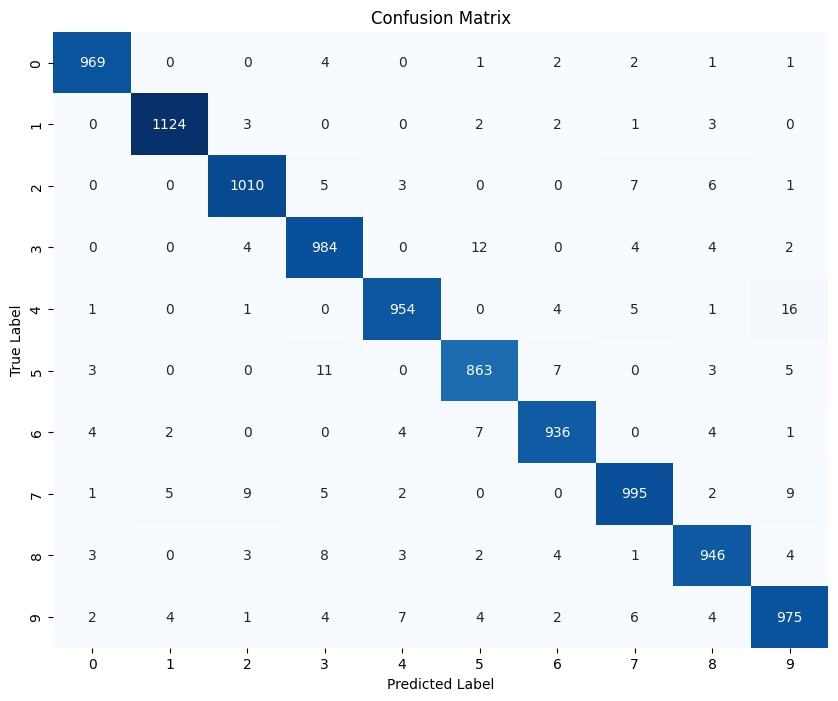

In [45]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(model, test_data):
    model.eval()
    with torch.no_grad():
        outputs = model(test_data.X)
        y_pred = outputs.argmax(1).cpu().numpy()

    y_true = test_data.y.cpu().numpy()

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=[str(i) for i in range(10)],
                yticklabels=[str(i) for i in range(10)])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

if acc1 >= acc2 and acc1 >= acc3:
    best_model = model
    best_name = "Modelo 1"
elif acc2 >= acc3:
    best_model = model2
    best_name = "Modelo 2"
else:
    best_model = model3
    best_name = "Modelo 3"

print(f"Mejor modelo: {best_name}")
plot_confusion_matrix(best_model, test_data)



Con esta actividad se pudo poner en práctica el entrenamiento de modelos por medio de pyTorch, se visualizó como un cambio en el modelo ya sea de capas ocultas, tamaño de batches, optimizador pueden causar cambios significativos en el desempeño.
Por ejemplo, el modelo1 utilizando Adam como optimizador dos capas oculptas y un batch size de 64 alcanzó buenos resultados sin embargo, mostró mucho overfitting teniendo perdida de loss en entrenamiento pero un aumento en la validación.

En el segundo caso sgd presentó ligeros mejores resultados en cuanto al overfitng, pero su rendimiento es muy parecido al modelo1,  para este modelo se utilizó GSD cómo optimizador, el modelo 3 con Adam pero con una diferencia de batches tuvo peores resultados, sin embargo los tres modelos están casi iguales.

Se utilizó un early stopping para evitar que el modelo se siga entrenando en un punto donde ya había pérdida de validación  y arriesgarse a un mayor overfitting.
